
---

# 📈 ***`Linear Regression in Machine Learning for Data Science`***  

**Linear Regression** is one of the most fundamental and widely used algorithms in **Machine Learning (ML) and Data Science**. It helps in **predicting a continuous numerical value** based on one or more independent variables.  

---

## ✅ **1. What is Linear Regression?**  

Linear Regression models the **relationship between input variables (X) and an output variable (Y)** using a **straight-line equation**:

$
Y = mX + b
$

Where:  
- **$ Y $** → Dependent variable (Target)  
- **$ X $** → Independent variable (Feature)  
- **$ m $** → Slope (Weight or Coefficient)  
- **$ b $** → Intercept (Bias)  

📌 **Key Idea:**  
- The model **learns the best-fitting line** that minimizes the error.  
- It assumes a **linear relationship** between **input (X) and output (Y)**.  

---

## 🎯 **2. Types of Linear Regression**  

| **Type** | **Formula** | **Use Case** |
|----------|------------|-------------|
| **Simple Linear Regression** | $ Y = mX + b $ | One feature, one target |
| **Multiple Linear Regression** | $ Y = m_1X_1 + m_2X_2 + \dots + b $ | Multiple features predicting one target |
| **Polynomial Regression** | $ Y = aX^2 + bX + c $ | Handles non-linearity using polynomial features |
| **Ridge Regression (L2 Regularization)** | $ Y = Xw + b + \lambda \lVert w \rVert^2 $                 | Avoids overfitting by penalizing large coefficients |
| **Lasso Regression (L1 Regularization)** | $ Y = Xw + b + \lambda \lvert w \rvert $                   | Reduces some coefficients to zero for feature selection |



---

## 📊 **3. How Does Linear Regression Work?**  

### **Step 1: Find the Best-Fitting Line**  
📌 **Goal:** Minimize the difference between **actual (Y)** and **predicted (Ŷ)** values.  

$
\hat{Y} = mX + b
$

### **Step 2: Minimize the Cost Function (MSE - Mean Squared Error)**  
$
MSE = \frac{1}{n} \sum_{i=1}^{n} (Y_i - \hat{Y}_i)^2
$

### **Step 3: Optimize Using Gradient Descent**  
- **Gradient Descent** updates coefficients \( m \) and \( b \) iteratively to minimize MSE.  
- The update rule:  
  $
  m = m - \alpha \frac{\partial}{\partial m} MSE
  $
  
  $
  b = b - \alpha \frac{\partial}{\partial b} MSE
  $
- **Learning rate (α):** Controls the step size in optimization.

---

## 🛠 **4. Implementing Linear Regression in Python**  

### **📁 Dataset Example**

Mean Squared Error: 46447.68133174533


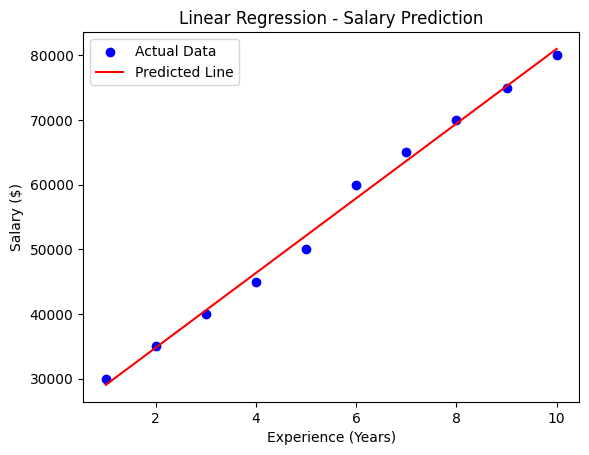

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Sample Dataset
data = {
    'Experience (Years)': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Salary ($)': [30000, 35000, 40000, 45000, 50000, 60000, 65000, 70000, 75000, 80000]
}
df = pd.DataFrame(data)

# Splitting Features and Target
X = df[['Experience (Years)']]
y = df['Salary ($)']

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# Plot Results
plt.scatter(X, y, color='blue', label="Actual Data")
plt.plot(X, model.predict(X), color='red', label="Predicted Line")
plt.xlabel("Experience (Years)")
plt.ylabel("Salary ($)")
plt.title("Linear Regression - Salary Prediction")
plt.legend()
plt.show()

📊 **Observations:**  
✔ **Red Line** → Best-Fitting Regression Line  
✔ **Blue Points** → Actual Data Points  
✔ **Low MSE** → Good model fit  

---

## 📉 **5. Multiple Linear Regression**  

📌 **When multiple features contribute to predicting the target:**  

$
Y = m_1X_1 + m_2X_2 + m_3X_3 + b
$

### **Example: Predicting House Prices**

In [26]:
# Sample Dataset (Features: Size, Bedrooms, Age)
data = {
    'Size (sq ft)': [1400, 1600, 1700, 1875, 1100],
    'Bedrooms': [3, 3, 2, 4, 2],
    'Age (years)': [20, 15, 30, 10, 25],
    'Price ($)': [250000, 280000, 290000, 330000, 200000]
}
df = pd.DataFrame(data)

# Splitting Features and Target
X = df[['Size (sq ft)', 'Bedrooms', 'Age (years)']]
y = df['Price ($)']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Model Coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

Intercept: 42903.22580645082
Coefficients: [ 154.83870968  645.16129032 -580.64516129]
Mean Squared Error: 14984391.259105332



📌 **Interpretation:**  
✔ **Each coefficient** represents the **impact of that feature** on the target.  
✔ **Intercept** → Base value when all features are zero.  

---

## 🎯 **6. Regularized Linear Regression (Ridge & Lasso)**  

**1️⃣ Ridge Regression (L2 Regularization)** 

$
Loss = MSE + \lambda \sum w^2
$

✔ **Prevents overfitting** by penalizing large coefficients.  

In [27]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

Ridge()


---

**2️⃣ Lasso Regression (L1 Regularization)** 

$
Loss = MSE + \lambda \sum |w|
$

✔ **Performs feature selection** by shrinking some coefficients to **zero**.  

In [28]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, y_train)

Lasso()


📌 **When to Use Ridge vs. Lasso?**  
- **Ridge** → When all features are important but need shrinkage.  
- **Lasso** → When feature selection is required.  

---

## 🔍 **7. Model Performance Evaluation**  

| **Metric** | **Formula** | **Interpretation** |
|------------|------------|---------------------|
| **Mean Squared Error (MSE)** | $ MSE = \frac{1}{n} \sum (Y - \hat{Y})^2 $| Lower is better |
| **Root Mean Squared Error (RMSE)** | $ RMSE = \sqrt{MSE} $ | Measures error in real units |
| **R² Score (Coefficient of Determination)** | $ R^2 = 1 - \frac{SS_{res}}{SS_{tot}} $ | Higher means better fit |

📌 **Example:**  

In [29]:
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings("ignore")

r2 = r2_score(y_test, y_pred)
print("R² Score:", r2)

R² Score: nan


---

## 🏆 **8. Key Takeaways**  

✔ **Linear Regression is the simplest & most interpretable ML model.**  
✔ **Assumes a linear relationship between features and target.**  
✔ **Can be extended using Ridge (L2) & Lasso (L1) regularization.**  
✔ **Evaluated using MSE, RMSE, and R² Score.**  
✔ **Use Multiple Linear Regression for multi-feature datasets.**  

💡 **Pro Tip:** Always **check residual plots** to ensure no strong patterns remain (indicating linearity assumption holds).

---


## ***`Implementing Simple Linear Regression`***

#### **Import Libraries** 

In [46]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    r2_score,
    mean_squared_error,
    root_mean_squared_error,
)

#### **Load the Dataset**

In [47]:
df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


#### **Plot a Scatter Plot between `total_bill` and `tip`**

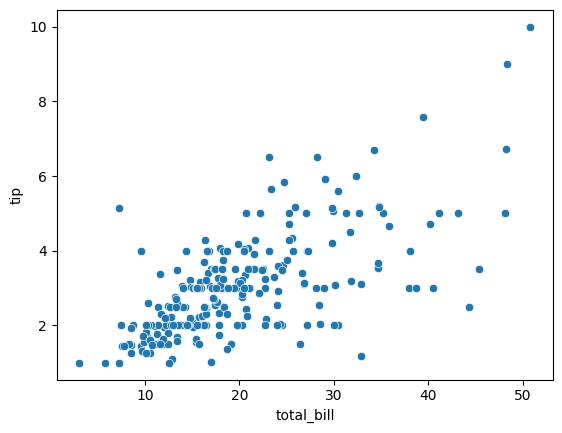

In [48]:
sns.scatterplot(data=df,x='total_bill',y='tip')
plt.show()

#### **Split the Data into X and y**

In [49]:
X = df[['total_bill']]
y = df['tip']

#### **Train test Split the Data**

In [50]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

#### **Implement the Linear Regression Model**

In [51]:
# call the model
clf = LinearRegression()

In [52]:
# train the model
clf.fit(X_train,y_train)

LinearRegression()

In [53]:
# predict with the model
y_pred = clf.predict(X_test)

In [54]:
# plot the intercept and slope / coefficent of the model
print("Intercept : ",clf.intercept_)
print("Slope / Coefficent : ",clf.coef_)

Intercept :  0.9252355585570546
Slope / Coefficent :  [0.10696371]


In [55]:
# evaluate the model
print("Mean Squared Error = ",mean_squared_error(y_test,y_pred))
print("Root Mean Squared Error = ",root_mean_squared_error(y_test,y_pred))
print("r2 Score = ",r2_score(y_test,y_pred))

Mean Squared Error =  0.5688142529229538
Root Mean Squared Error =  0.7541977545199626
r2 Score =  0.5449381659234663


#### **Plot the Model Results**

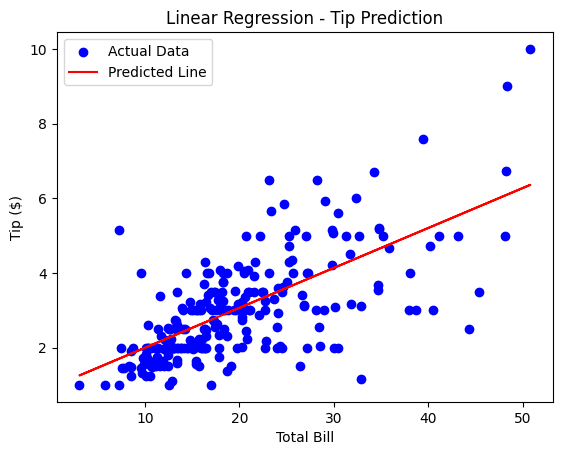

In [57]:
# Plot Results
plt.scatter(X, y, color='blue', label="Actual Data")
plt.plot(X, clf.predict(X), color='red', label="Predicted Line")
plt.xlabel("Total Bill")
plt.ylabel("Tip ($)")
plt.title("Linear Regression - Tip Prediction")
plt.legend()
plt.show()

---